In [1]:
from sklearn.metrics import precision_score,recall_score,accuracy_score
from xgboost import XGBClassifier
import pandas as pd
from eda.scoring_function import score_model_optimal_k
from model_pipelines.check_calibration import *
from model_pipelines.first_level_feature_selectors import Kolmogorov_Smirnov_selector,reduce_multicollinearity
from model_pipelines.xgb_classifier import *
from model_pipelines.auxilliary_functions import *
import os
from pathlib import Path
from scipy.stats import ks_2samp
import numpy as np
import matplotlib.pyplot as plt

from model_pipelines.xgb_classifier import cv_xgb_hyperparameter_grid_optimizer


C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_FOLDER_NAME = "-Cost-Sensitive-Predictive-Modeling"
current_path = Path(os.getcwd()).resolve()
project_root = Path(*current_path.parts[:current_path.parts.index(PROJECT_FOLDER_NAME) + 1])

thrid_layer_experiment_dir=project_root / "experiment_results" / "xgb_common" # to get other experiment just change the last element.

In [3]:
y=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")
x=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")
x_test=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_test.txt",sep=" ")


# analysis of xgb selection results
xgb importance selection proved to be the best based on earlier experiments

In [4]:
subset_reference_dict=load_dict_from_json(Path(thrid_layer_experiment_dir / "all_subsets_dict.json"))
cv_results=load_dict_from_json(Path(thrid_layer_experiment_dir / "top10_subsets_cv_dict.json"))
multirun_results=load_dict_from_json(Path(thrid_layer_experiment_dir / "top10_subsets_mulitrun_check_dict.json"))

In [5]:
auxliary_data = [
    {'ind': key, 'precision': value['precision'],'accuracy':value['accuracy'],'custom_score': value['cv_custom_score'], 'best_threshold': value['cv_best_threshold']}
    for key, value in cv_results.items()
]
cv_df=pd.DataFrame(auxliary_data)
cv_df["variable_list"] = cv_df["ind"].map(subset_reference_dict)
cv_df["number_of_vars_used"] = cv_df["variable_list"].str.len().fillna(0).astype(int)
cv_df.sort_values(by="custom_score", ascending=False)

,ind,precision,accuracy,custom_score,best_threshold,variable_list,number_of_vars_used
0,61,0.754755,0.6042,5325,0.670104,"[V215, V380, V255, V191, V160]",5
5,46,0.754755,0.6042,5325,0.635404,"[V342, V215, V380, V255, V160]",5
4,58,0.752753,0.6034,5295,0.667163,"[V342, V215, V255, V191, V160]",5
9,29,0.733734,0.5958,5210,0.626379,"[V215, V380, V255, V191]",4
3,54,0.746747,0.6010,5205,0.635846,"[V342, V215, V380, V191, V160]",5
1,62,0.758275,0.6054,5165,0.717112,"[V342, V215, V380, V255, V191, V160]",6
8,94,0.751752,0.6030,5080,0.687464,"[V342, V215, V380, V255, V191, V176]",6
2,126,0.763764,0.6078,5060,0.735376,"[V342, V215, V380, V255, V191, V160, V176]",7
6,110,0.749750,0.6022,5050,0.714487,"[V342, V215, V380, V255, V160, V176]",6
7,125,0.745746,0.6006,4990,0.719762,"[V215, V380, V255, V191, V160, V176]",6


In [6]:
multirun_statistics= [
    {'ind': key, 'mean_precision': np.mean(value['precs']),'median_precision': np.median(value['precs']), 'min_precision': min(value['precs']),'max_precision': max(value['precs']), 'mean_score': np.mean(value['scores']),'median_score': np.median(value['scores']),'min_score': min(value['scores']),'max_score': max(value['scores'])}
    for key, value in multirun_results.items()
]
multirun_df=pd.DataFrame(multirun_statistics)
multirun_df["variable_list"] = multirun_df["ind"].map(subset_reference_dict)
multirun_df["number_of_vars_used"] = multirun_df["variable_list"].str.len().fillna(0).astype(int)
multirun_df.sort_values(by="median_score", ascending=False)

,ind,mean_precision,median_precision,min_precision,max_precision,mean_score,median_score,min_score,max_score,variable_list,number_of_vars_used
4,58,0.762240,0.760102,0.705584,0.823864,1068.7,1067.5,930.0,1250.0,"[V342, V215, V255, V191, V160]",5
1,62,0.769162,0.769052,0.715640,0.827751,1067.1,1057.5,875.0,1250.0,"[V342, V215, V380, V255, V191, V160]",6
8,94,0.762442,0.765182,0.687500,0.826923,1048.7,1057.5,845.0,1250.0,"[V342, V215, V380, V255, V191, V176]",6
0,61,0.751670,0.752435,0.693467,0.802326,1047.9,1050.0,875.0,1185.0,"[V215, V380, V255, V191, V160]",5
5,46,0.754602,0.754190,0.671958,0.808743,1060.7,1050.0,840.0,1205.0,"[V342, V215, V380, V255, V160]",5
3,54,0.744632,0.744131,0.685590,0.801932,1054.4,1050.0,870.0,1230.0,"[V342, V215, V380, V191, V160]",5
7,125,0.764363,0.763886,0.690608,0.819876,1031.2,1047.5,845.0,1175.0,"[V215, V380, V255, V191, V160, V176]",6
9,29,0.732429,0.732381,0.676724,0.808290,1047.2,1045.0,910.0,1225.0,"[V215, V380, V255, V191]",4
6,110,0.762078,0.757813,0.684492,0.823810,1046.0,1027.5,830.0,1230.0,"[V342, V215, V380, V255, V160, V176]",6
2,126,0.762248,0.763159,0.687500,0.816993,991.8,1002.5,780.0,1155.0,"[V342, V215, V380, V255, V191, V160, V176]",7


In [7]:
all_features_in_top_10=find_sum_of_arrays(*multirun_df["variable_list"])
print(all_features_in_top_10)
common_features_in_top10=find_common_elements(*multirun_df["variable_list"])
print(common_features_in_top10)

['V215', 'V176', 'V255', 'V191', 'V342', 'V380', 'V160']
['V215']


In [30]:
#check how different are the distributions of features on classes (using ks test):
ks_class_diff_df=Kolmogorov_Smirnov_selector(x.loc[:,all_features_in_top_10],y,len(all_features_in_top_10))[1]
print(ks_class_diff_df)

  feature  ks_statistic
3    V255      0.108226
1    V176      0.104080
0    V191      0.098506
5    V160      0.074932
4    V380      0.068425
6    V342      0.066439
2    V215      0.059174


In [24]:

# check if any feature used has significantly different distribution in test set with Kolmogorov-Smirnov Test
ks_results = []
for ft in all_features_in_top_10:
    stat, _ = ks_2samp(x[ft], x_test[ft])
    ks_results.append({
        'feature': ft,
        'ks_statistic': stat
    })
print(ks_results)


[{'feature': 'V191', 'ks_statistic': np.float64(0.0114)}, {'feature': 'V176', 'ks_statistic': np.float64(0.0212)}, {'feature': 'V215', 'ks_statistic': np.float64(0.016)}, {'feature': 'V255', 'ks_statistic': np.float64(0.017)}, {'feature': 'V380', 'ks_statistic': np.float64(0.012)}, {'feature': 'V160', 'ks_statistic': np.float64(0.021)}, {'feature': 'V342', 'ks_statistic': np.float64(0.0156)}]


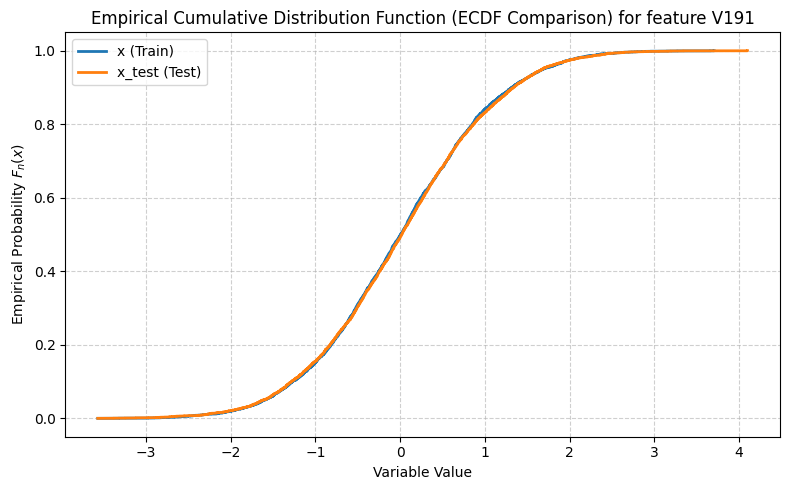

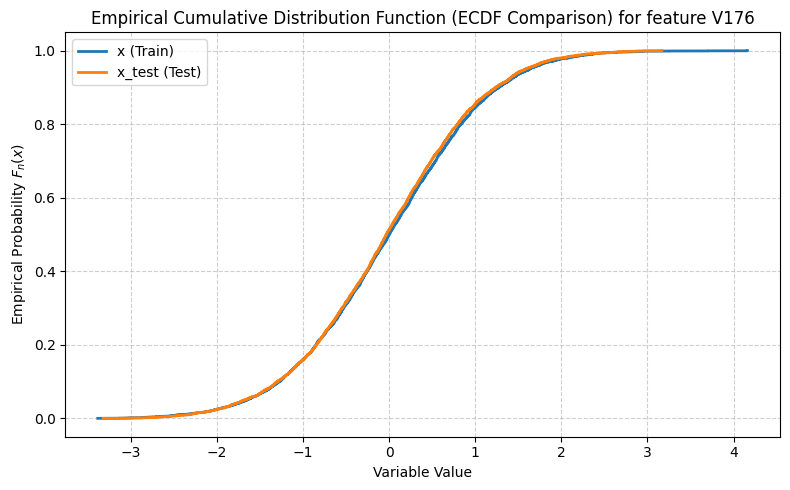

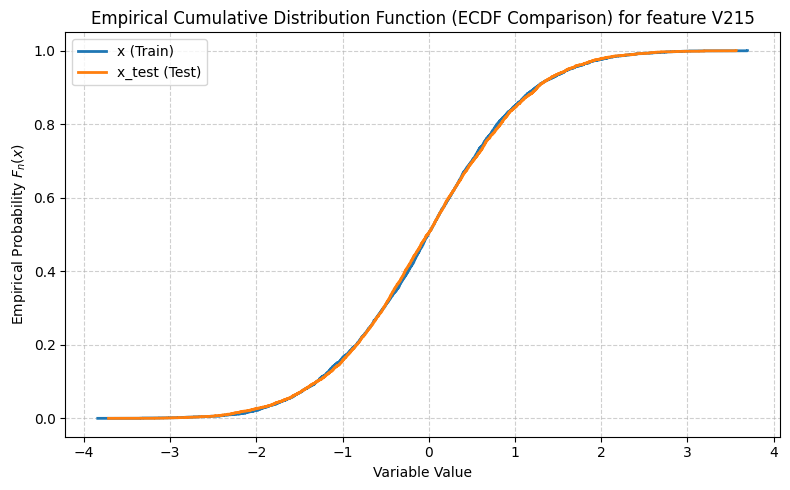

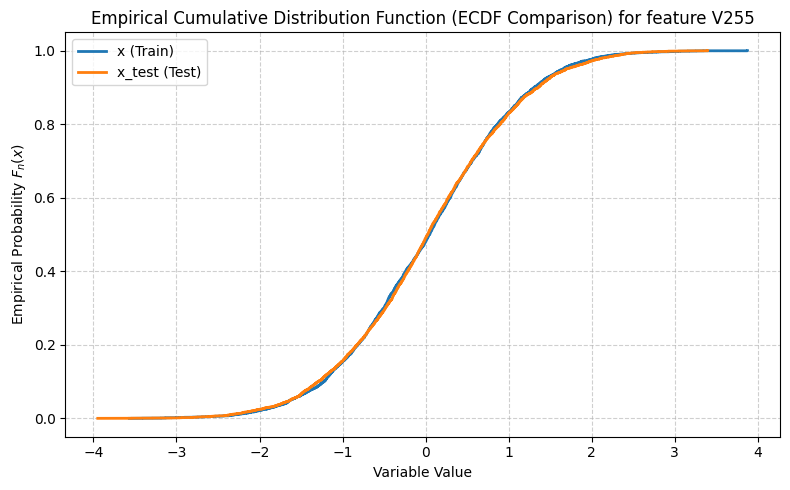

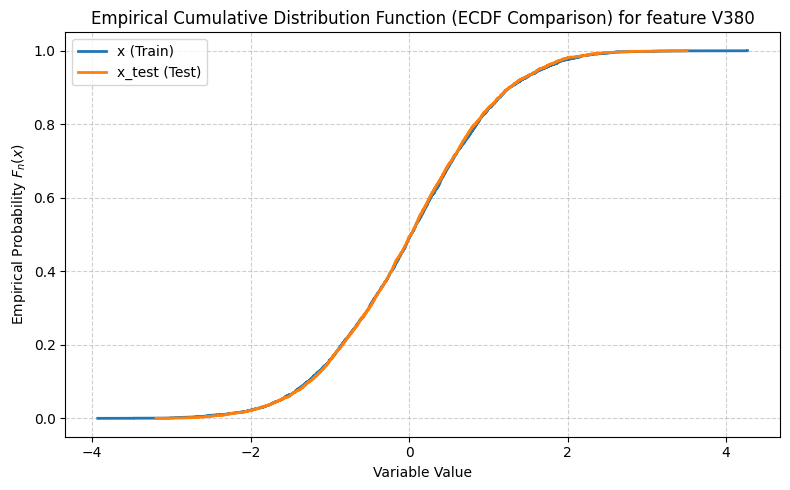

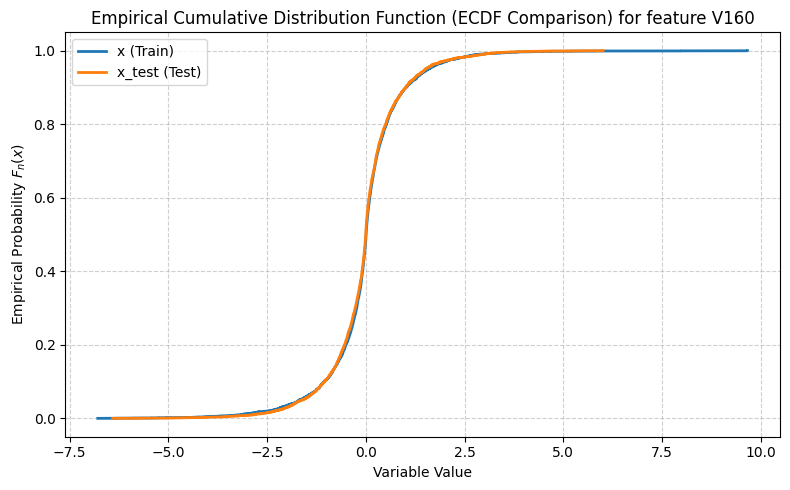

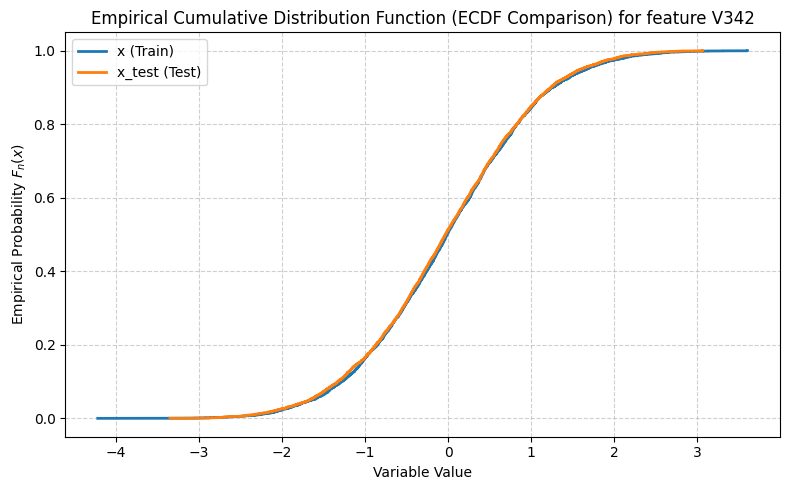

In [25]:
def compute_ecdf(data):
    x_sorted = np.sort(data)
    y_values = np.arange(1, len(data) + 1) / len(data)
    return x_sorted, y_values
for ft in all_features_in_top_10:
    x_ecdf, y_ecdf = compute_ecdf(x[ft])
    x_test_ecdf, y_test_ecdf = compute_ecdf(x_test[ft])

    # Plotting the distributions
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.step(x_ecdf, y_ecdf, label='x (Train)', where='post', linewidth=2)
    ax.step(x_test_ecdf, y_test_ecdf, label='x_test (Test)', where='post', linewidth=2)

    # Formatting
    ax.set_title(f'Empirical Cumulative Distribution Function (ECDF Comparison) for feature {ft}')
    ax.set_xlabel('Variable Value')
    ax.set_ylabel('Empirical Probability $F_n(x)$')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    plt.tight_layout()
    # plt.savefig('empirical_distribution_ecdf.png', dpi=300)
    plt.show()

# try features derived from the selected ones
only for 3 best subsets based on cv.

In [8]:
best_subsets=cv_df.sort_values(by="custom_score", ascending=False).head(3)['ind'].to_list()
print(best_subsets)

[61, 46, 58]


In [11]:
indices = [str(item) for item in best_subsets] + [str(item) + "e" for item in best_subsets]
print(indices)

['61', '46', '58', '61e', '46e', '58e']


In [12]:
top3_cv_hyperparameter_tuning_result_dict = {
    idx: {}
    for idx in indices
}

In [15]:
for subset in best_subsets:
    print("=========================================")
    print(f"subset {subset}: {subset_reference_dict[subset]}")
    print("=========================================")
    subset_size=len(subset_reference_dict[subset])
    key=str(subset)
    best_c_hyperparams,best_p_hyperparams=cv_xgb_hyperparameter_grid_optimizer(x.loc[:,subset_reference_dict[subset]],y)
    print(f"best custom score hyperparams: {best_c_hyperparams}")
    print(f"best precision hyperparams: {best_p_hyperparams}")
    xgb=XGBClassifier(max_depth=best_c_hyperparams['max_depth'],n_estimators=best_c_hyperparams['n_estimators'],learning_rate=best_c_hyperparams['lr'],random_state=7)
    all_y_test,all_y_prob=get_cv_calibration_predictions(xgb,x.loc[:,subset_reference_dict[subset]],y)
    cv_cust_score,cv_best_thr=score_model_optimal_k(all_y_test,all_y_prob,n_vars=subset_size  ,keep_fp_tp=True)[:2]
    all_y_pred=(all_y_prob>cv_best_thr).astype(int)
    prec=precision_score(all_y_test,all_y_pred)
    top3_cv_hyperparameter_tuning_result_dict[key]['precision']=prec
    top3_cv_hyperparameter_tuning_result_dict[key]['c_hyperparams']=best_c_hyperparams
    top3_cv_hyperparameter_tuning_result_dict[key]['p_hyperparams']=best_p_hyperparams
    top3_cv_hyperparameter_tuning_result_dict[key]['custom_score']=cv_cust_score
    top3_cv_hyperparameter_tuning_result_dict[key]['cv_best_thr']=cv_best_thr
    top3_cv_hyperparameter_tuning_result_dict[key]['recall']=recall_score(all_y_test,all_y_pred)
    top3_cv_hyperparameter_tuning_result_dict[key]['accuracy']=accuracy_score(all_y_test,all_y_pred)
    print(f"cv precision: {prec}")
    print(f"cv_custom_score: {cv_cust_score}")
    print(f"cv_best_thr: {cv_best_thr}")
    print("=========================================")
    print(f"subset {subset}: {subset_reference_dict[subset]} enhanced with squared addition interactions")
    print("=========================================")
    enhanced=add_interaction_features(x.loc[:,subset_reference_dict[subset]],subset_reference_dict[subset],'add',2)
    key=str(subset)+'e'
    best_c_hyperparams,best_p_hyperparams=cv_xgb_hyperparameter_grid_optimizer(enhanced,y)
    print(f"best custom score hyperparams: {best_c_hyperparams}")
    print(f"best precision hyperparams: {best_p_hyperparams}")
    xgb=XGBClassifier(max_depth=best_c_hyperparams['max_depth'],n_estimators=best_c_hyperparams['n_estimators'],learning_rate=best_c_hyperparams['lr'],random_state=7)
    all_y_test,all_y_prob=get_cv_calibration_predictions(xgb,enhanced,y)
    cv_cust_score,cv_best_thr=score_model_optimal_k(all_y_test,all_y_prob,n_vars=subset_size  ,keep_fp_tp=True)[:2]
    all_y_pred=(all_y_prob>cv_best_thr).astype(int)
    prec=precision_score(all_y_test,all_y_pred)
    top3_cv_hyperparameter_tuning_result_dict[key]['precision']=prec
    top3_cv_hyperparameter_tuning_result_dict[key]['c_hyperparams']=best_c_hyperparams
    top3_cv_hyperparameter_tuning_result_dict[key]['p_hyperparams']=best_p_hyperparams
    top3_cv_hyperparameter_tuning_result_dict[key]['custom_score']=cv_cust_score
    top3_cv_hyperparameter_tuning_result_dict[key]['cv_best_thr']=cv_best_thr
    top3_cv_hyperparameter_tuning_result_dict[key]['recall']=recall_score(all_y_test,all_y_pred)
    top3_cv_hyperparameter_tuning_result_dict[key]['accuracy']=accuracy_score(all_y_test,all_y_pred)
    print(f"cv precision: {prec}")
    print(f"cv_custom_score: {cv_cust_score}")
    print(f"cv_best_thr: {cv_best_thr}")
save_dict_to_json(top3_cv_hyperparameter_tuning_result_dict,Path(project_root / "experiment_results" /"final_run_results"/"cv_hyperparam_tuning_dict.json"))




subset 61: ['V215', 'V380', 'V255', 'V191', 'V160']
best custom score hyperparams: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.1}
best precision hyperparams: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.1}
cv precision: 0.7497497497497497
cv_custom_score: 5250
cv_best_thr: 0.6699750423431396
subset 61: ['V215', 'V380', 'V255', 'V191', 'V160'] enhanced with squared addition interactions
best custom score hyperparams: {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}
best precision hyperparams: {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}
cv precision: 0.7048192771084337
cv_custom_score: 4560
cv_best_thr: 0.763249397277832
subset 46: ['V342', 'V215', 'V380', 'V255', 'V160']
best custom score hyperparams: {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}
best precision hyperparams: {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}
cv precision: 0.7197197197197197
cv_custom_score: 4800
cv_best_thr: 0.7397075891494751
subset 46: ['V342', 'V215', 'V380', 'V255', 'V160'] enhanced wi

In [7]:
top3_cv_hyperparameter_tuning_result_dict=load_dict_from_json(Path(project_root / "experiment_results" /"final_run_results"/"cv_hyperparam_tuning_dict.json"),make_numeric_keys=False)
print(top3_cv_hyperparameter_tuning_result_dict)

{'61': {'precision': 0.7497497497497497, 'c_hyperparams': {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.1}, 'p_hyperparams': {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.1}, 'custom_score': 5250, 'cv_best_thr': 0.6699750423431396, 'recall': 0.30104501607717044, 'accuracy': 0.6022}, '46': {'precision': 0.7197197197197197, 'c_hyperparams': {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}, 'p_hyperparams': {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}, 'custom_score': 4800, 'cv_best_thr': 0.7397075891494751, 'recall': 0.2889871382636656, 'accuracy': 0.5902}, '58': {'precision': 0.7297297297297297, 'c_hyperparams': {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}, 'p_hyperparams': {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}, 'custom_score': 4950, 'cv_best_thr': 0.7467660903930664, 'recall': 0.2930064308681672, 'accuracy': 0.5942}, '61e': {'precision': 0.7048192771084337, 'c_hyperparams': {'max_depth': 3, 'n_estimators': 1000, 'lr': 0.1}, 'p_hyperparams': {'max_depth': 3, 'n_

In [8]:
# Define the key
key = '61'

# Instantiate the XGBClassifier using the hyperparameters from the top3 dict
xgb_best = XGBClassifier(
    max_depth=top3_cv_hyperparameter_tuning_result_dict[key]['c_hyperparams']['max_depth'],
    n_estimators=top3_cv_hyperparameter_tuning_result_dict[key]['c_hyperparams']['n_estimators'],
    learning_rate=top3_cv_hyperparameter_tuning_result_dict[key]['c_hyperparams']['lr'],
    random_state=7
)

In [9]:
enhanced1=add_interaction_features(x.loc[:,subset_reference_dict[61]],['V380','V160','V215','V255'],'add',2)
#enhanced1=enhanced1.drop(['V215','V160','V380'], axis=1)
xgb_best.fit(enhanced1,y)
# 1. Extract feature importances and pair them with column names
feature_importances = xgb_best.feature_importances_
feature_names = enhanced1.columns

# 2. Create a readable DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# 3. Sort by importance in descending order and reset the index
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the dataframe
print(importance_df)

              Feature  Importance
0   V380**2_+_V160**2    0.186135
1                V191    0.175589
2   V160**2_+_V215**2    0.107155
3   V380**2_+_V215**2    0.103288
4   V160**2_+_V255**2    0.091335
5   V380**2_+_V255**2    0.090459
6   V215**2_+_V255**2    0.089863
7                V255    0.064670
8                V160    0.035729
9                V380    0.029157
10               V215    0.026619


In [10]:
vif_cleaned_enhanced=reduce_multicollinearity(enhanced1)
print(vif_cleaned_enhanced.columns)

Dropping 'V160**2_+_V215**2' (VIF: inf)
Dropping 'V215**2_+_V255**2' (VIF: inf)
Dropping 'V380**2_+_V160**2' (VIF: 6.71)

Feature reduction complete.
Index(['V215', 'V380', 'V255', 'V191', 'V160', 'V380**2_+_V215**2',
       'V380**2_+_V255**2', 'V160**2_+_V255**2'],
      dtype='str')


C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [15]:
xgb_best.fit(vif_cleaned_enhanced,y)
# 1. Extract feature importances and pair them with column names
feature_importances = xgb_best.feature_importances_
feature_names = vif_cleaned_enhanced.columns

# 2. Create a readable DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# 3. Sort by importance in descending order and reset the index
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the dataframe
print(importance_df)

             Feature  Importance
0  V380**2_+_V215**2    0.292205
1  V160**2_+_V255**2    0.264316
2               V191    0.175089
3               V255    0.086817
4               V160    0.059798
5  V380**2_+_V255**2    0.047781
6               V380    0.037112
7               V215    0.036882


Bin  1 | n= 500 | mean_pred=0.230 | frac_pos=0.282
Bin  2 | n= 500 | mean_pred=0.298 | frac_pos=0.324
Bin  3 | n= 500 | mean_pred=0.347 | frac_pos=0.358
Bin  4 | n= 500 | mean_pred=0.392 | frac_pos=0.412
Bin  5 | n= 500 | mean_pred=0.440 | frac_pos=0.442
Bin  6 | n= 500 | mean_pred=0.495 | frac_pos=0.488
Bin  7 | n= 500 | mean_pred=0.560 | frac_pos=0.552
Bin  8 | n= 500 | mean_pred=0.636 | frac_pos=0.614
Bin  9 | n= 500 | mean_pred=0.721 | frac_pos=0.722
Bin 10 | n= 500 | mean_pred=0.854 | frac_pos=0.782


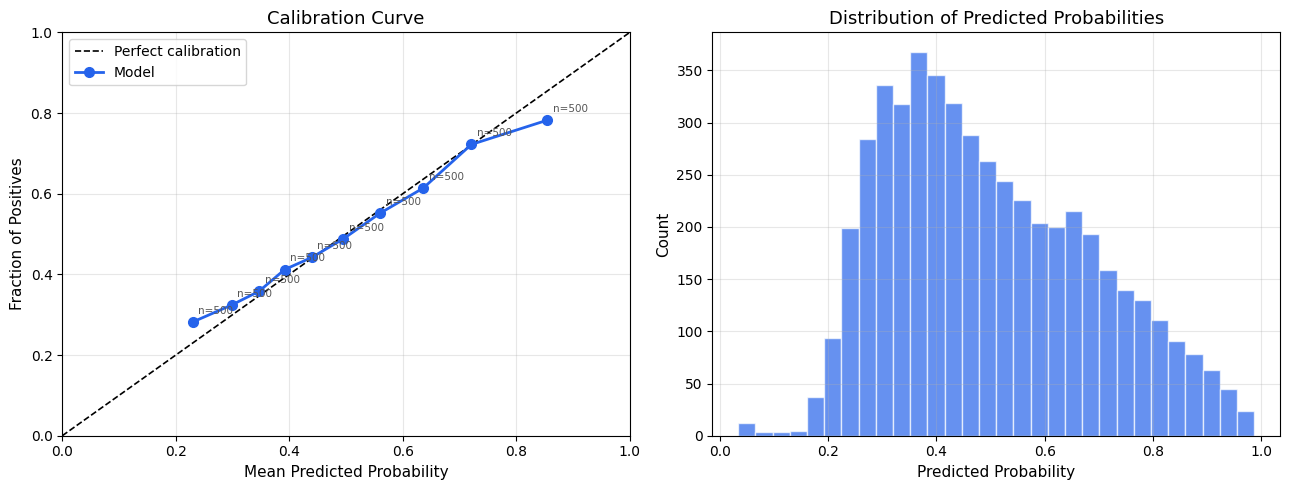

In [16]:
all_y_test,all_y_prob=get_cv_calibration_predictions(xgb_best,vif_cleaned_enhanced,y)
check_calibration(all_y_prob,all_y_test)

In [ ]:
model=xgb_best = XGBClassifier(
    max_depth=top3_cv_hyperparameter_tuning_result_dict['61']['c_hyperparams']['max_depth'],
    n_estimators=top3_cv_hyperparameter_tuning_result_dict['61']['c_hyperparams']['n_estimators'],
    learning_rate=top3_cv_hyperparameter_tuning_result_dict['61']['c_hyperparams']['lr'],
    random_state=7
)
all_y_test,all_y_prob=get_cv_calibration_predictions(model,vif_cleaned_enhanced,y)
all_y_pred=(all_y_prob>score_model_optimal_k(all_y_test,all_y_prob,n_vars=5)[1]).astype(int)
print(precision_score(all_y_test,all_y_pred))
print(score_model_optimal_k(all_y_test,all_y_prob,n_vars=5)[0])

# final comparison of different hyperparams on feature subset [ "V342", "V215","V380", "V255","V160"] with and without derived features and with different hyperparams]

In [11]:
import itertools

hyperparam_grid = {
    "lr": [0.1],  # Wrapped in a list for iteration
    "n_estimators": [500, 1000, 2000, 3000],
    "max_depth": [1, 2, 3]
}

keys = hyperparam_grid.keys()
values = hyperparam_grid.values()
combinations = itertools.product(*values)

combinations_dict = {i: dict(zip(keys, combo)) for i, combo in enumerate(combinations)}

print(combinations_dict)

{0: {'lr': 0.1, 'n_estimators': 500, 'max_depth': 1}, 1: {'lr': 0.1, 'n_estimators': 500, 'max_depth': 2}, 2: {'lr': 0.1, 'n_estimators': 500, 'max_depth': 3}, 3: {'lr': 0.1, 'n_estimators': 1000, 'max_depth': 1}, 4: {'lr': 0.1, 'n_estimators': 1000, 'max_depth': 2}, 5: {'lr': 0.1, 'n_estimators': 1000, 'max_depth': 3}, 6: {'lr': 0.1, 'n_estimators': 2000, 'max_depth': 1}, 7: {'lr': 0.1, 'n_estimators': 2000, 'max_depth': 2}, 8: {'lr': 0.1, 'n_estimators': 2000, 'max_depth': 3}, 9: {'lr': 0.1, 'n_estimators': 3000, 'max_depth': 1}, 10: {'lr': 0.1, 'n_estimators': 3000, 'max_depth': 2}, 11: {'lr': 0.1, 'n_estimators': 3000, 'max_depth': 3}}


In [12]:
selected_set_final_comparison_dict={
    "subset":[ "V342", "V215","V380", "V255","V160"],
    "enhanced_subset":vif_cleaned_enhanced.columns.tolist(),
    "hyperparam_grid":combinations_dict,
    "results":{
        key:{
            "pure":{},
            "enhanced":{}
        } for key in combinations_dict.keys()
    }
}